In [113]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import pandas as pd
from matplotlib.figure import figaspect
import matplotlib.gridspec as gridspec
from utility.data import get_dataset_info, map_dataset_name, map_strategy_name
import config as cfg

# Set Matplotlib style
matplotlib_style = 'default'
import matplotlib.pyplot as plt
plt.style.use(matplotlib_style)
plt.rcParams.update({'axes.labelsize': 'medium',
                     'axes.titlesize': 'medium',
                     'font.size': 14.0})

color_list = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Load results
results = pd.read_csv(Path.joinpath(cfg.RESULTS_DIR, "semisynthetic_results.csv"))

# Take average over seed
results = results.loc[results['Seed'] == 0]

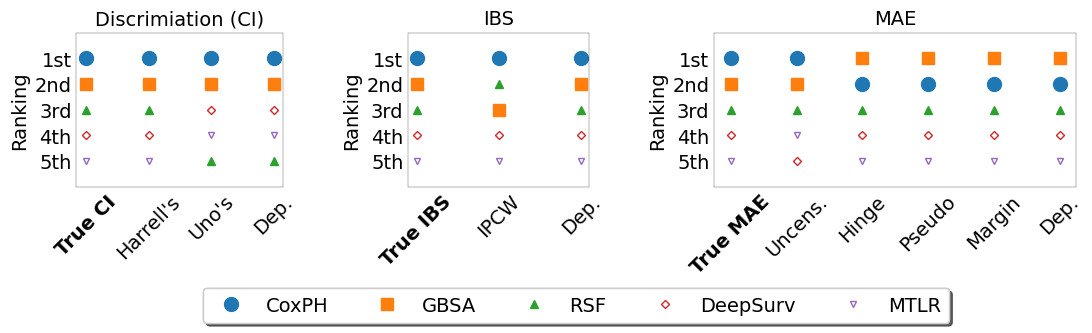

In [ ]:
# Define metrics
metrics = ["CIHarrell", "CIUno", "CIDepIPCW", "IBSIPCW", "IBSDepBG",
           "MAEUncens", "MAEHinge", "MAEPseudo", "MAEMargin", "MAEDepBG"]

dataset = "seer_liver" # seer_liver, random_25
strategy = 'top_5'

# Define metric groups
metric_groups_dict = {
    "CI": ['True CI', 'Harrell\'s', 'Uno\'s', 'Dep.'],
    "IBS": ['True IBS', 'IPCW', 'Dep.'],
    "MAE": ['True MAE', 'Uncens.', 'Hinge', 'Pseudo', 'Margin', 'Dep.']
}

# Compute max number of metrics for width adjustment
max_metrics = max(len(v) for v in metric_groups_dict.values())

# Adjust figure size dynamically (base width 2 per metric)
fig_width = 2 * max_metrics  # Scale based on the max number of metrics
fig_height = 3  # Keep height fixed

fig = plt.figure(figsize=(10, 2))
gs = gridspec.GridSpec(1, 3, width_ratios=[8, 7, 14])
axs = [plt.subplot(gs[i]) for i in range(3)]

ranking = ['1st', '2nd', '3rd', '4th', '5th']
model_names = ["CoxPH", "GBSA", "RSF", "DeepSurv", "MTLR"]

markers = ['o', 's', '^', 'D', 'v']

# Filter dataset and strategy
results = results.loc[results['Dataset'] == dataset]
results = results.loc[results['Strategy'] == strategy]

size = [10, 8, 6, 4, 4]

# Plot for each metric group
for col_idx, (metric_group, metrics_names) in enumerate(metric_groups_dict.items()):
    if metric_group == "CI":
        rank_idx = results['CITrue'].values.argsort()
        true_ci = results['CITrue'].values[rank_idx]
        harrell_ci = results['CIHarrell'].values[rank_idx]
        uno_ci = results['CIUno'].values[rank_idx]
        dep_ci = results['CIDepIPCW'].values[rank_idx]

        x = np.arange(len(metrics_names))
        
        for i, model_name in enumerate(model_names):
            order = np.array([i, harrell_ci.argsort()[i], uno_ci.argsort()[i], dep_ci.argsort()[i]])
            axs[col_idx].plot(x, order + 1, marker=markers[i], label=model_name, ms=size[i],
                              markerfacecolor='none' if i >= 3 else color_list[i], color=color_list[i],
                              linestyle="None")
    
        axs[col_idx].set_title("Discrimiation (CI)")
    
    elif metric_group == "IBS":
        rank_idx = results['IBSTrue'].values.argsort()
        true_ibs = results['IBSTrue'].values[rank_idx]
        ipcw_ibs = results['IBSIPCW'].values[rank_idx]
        dep_ibs = results['IBSDepBG'].values[rank_idx]

        x = np.arange(len(metrics_names))

        for i in range(len(model_names)):
            order = np.array([i, ipcw_ibs.argsort()[i], dep_ibs.argsort()[i]])
            axs[col_idx].plot(x, order + 1, marker=markers[i], label=model_name, ms=size[i],
                              markerfacecolor='none' if i >= 3 else color_list[i], color=color_list[i],
                              linestyle="None")
            
        axs[col_idx].set_title("Accuracy (IBS)")
        
    elif metric_group == "MAE":
        rank_idx = results['MAETrue'].values.argsort()
        true_mae = results['MAETrue'].values[rank_idx]
        uncensor = results['MAEUncens'].values[rank_idx]
        hinge = results['MAEHinge'].values[rank_idx]
        pseudo = results['MAEPseudo'].values[rank_idx]
        margin = results['MAEMargin'].values[rank_idx]
        dependent = results['MAEDepBG'].values[rank_idx]

        x = np.arange(len(metrics_names))

        for i in range(len(model_names)):
            order = np.array([i, uncensor.argsort()[i], hinge.argsort()[i], pseudo.argsort()[i], 
                              margin.argsort()[i], dependent.argsort()[i]])
            axs[col_idx].plot(x, order + 1, marker=markers[i], label=model_name, ms=size[i],
                              markerfacecolor='none' if i >= 3 else color_list[i], color=color_list[i],
                              linestyle="None")

        axs[col_idx].set_title("Accuracy (MAE)")

    axs[col_idx].set_xticks(x)
    axs[col_idx].set_xticklabels(metrics_names, rotation=45)[0].set_weight("bold")
    axs[col_idx].set_yticks(np.arange(1, 6))
    axs[col_idx].set_yticklabels(ranking)
    axs[col_idx].set_ylim(6, 0)
    axs[col_idx].set_ylabel('Ranking')

    axs[col_idx].tick_params(axis='y', which='both', length=0)
    axs[col_idx].tick_params(axis='x', which='both', length=0)
    
    # Set spines visibility
    axs[col_idx].spines['top'].set_visible(True)  # Remove top spine
    axs[col_idx].spines['right'].set_visible(True)  # Remove right spine
    axs[col_idx].spines['bottom'].set_visible(True)  # Keep bottom spine
    axs[col_idx].spines['left'].set_visible(True)  # Keep left spine
    
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=len(model_names), fancybox=True, shadow=True)
        
for ax in axs:
    for spine in ax.spines.values():
        spine.set_linewidth(0.2)  # Set the spine thickness (adjust as needed)
        
#fig.subplots_adjust(wspace=0.5)
fig.subplots_adjust(left=0, right=1, wspace=0.5)

# Save figure
plt.savefig(f"{cfg.PLOTS_DIR}/ranking_error_{dataset}_{strategy}.pdf", format='pdf', bbox_inches='tight')

# Show the plot
plt.show()